# 三节点非负单调协同 ODE 点火实验

本 notebook 只保留最新的三节点动力系统实验：比较单源点火与双源点火如何改变目标节点 $x_2(T)$，并用 EI 分解量化 $x_0,x_1$ 对目标响应的双源协同。旧的跨模型灵敏度扫描已移除，相关可复用实现放在 `exp.network_revival.sin_synergy_ignition` 中。

## 动力系统

实验使用非负单调联合项，源节点在点火窗口内被固定为干预幅度，目标节点按下式响应：

\begin{aligned}
\dot{x}_0 &= -\lambda_s x_0,\\
\dot{x}_1 &= -\lambda_s x_1,\\
\dot{x}_2 &= -\lambda_t x_2 + \alpha \log(1 + \max(g x_0 x_1, 0)) + (1-\alpha)\rho(x_0 + \epsilon x_1).
\end{aligned}

$\alpha$ 控制双源联合项强度；$\epsilon$ 让节点 1 保留很弱的单源通道，便于区分“单源可用但弱”和“双源协同打开”的两种响应。

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / "exp" / "network_revival").exists():
    pass
elif REPO_ROOT.name == "network_revival":
    REPO_ROOT = REPO_ROOT.parents[1]
elif REPO_ROOT.name == "exp":
    REPO_ROOT = REPO_ROOT.parent
else:
    for parent in REPO_ROOT.parents:
        if (parent / "exp" / "network_revival").exists():
            REPO_ROOT = parent
            break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.network_revival.sin_synergy_ignition import (
    MultiNodeSynergyIgnitionConfig,
    build_multi_node_pair_ignition_table,
    estimate_multi_node_pair_synergy,
    load_or_run_multi_node_synergy_experiment,
    multi_node_output_paths,
    plot_multi_node_synergy_figures,
    summarize_multi_node_synergy_results,
    SinSynergyIgnitionConfig,
    build_sin_synergy_alpha_sweep,
    build_sin_synergy_pair_duration_surface,
    estimate_sin_synergy_ei_decomposition,
    estimate_sin_synergy_ei_time_curve,
    evaluate_sin_synergy_ignition,
    load_or_run_sin_synergy_experiment,
    make_sin_synergy_ignition_model,
    monotone_synergy_nonlinearity,
    plot_sin_synergy_figures,
    sin_output_paths,
    summarize_sin_synergy_results,
    write_sin_synergy_figure_manifest,
)

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linewidth": 0.8,
})

In [2]:
FORCE_RECOMPUTE = False

OUTPUT_DIR = REPO_ROOT / "results" / "network_revival_three_node_synergy"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_MANIFEST_JSON = OUTPUT_DIR / "figure_manifest.json"
FIGURE_NOTES_MD = OUTPUT_DIR / "figure_notes.md"

SIN_NONLINEARITY = "log1p_product"
SIN_GAIN = 1.0
SIN_SOURCE_DECAY = 1.0
SIN_TARGET_DECAY = 1.0
SIN_SOURCE_WEIGHT = 1.0
SIN_SECONDARY_SOURCE_WEIGHT = 0.01
SIN_ALPHA_LOW = 0.05
SIN_ALPHA_HIGH = 0.9
SIN_EI_COST_LOW = 0.0
SIN_EI_COST_HIGH = 2.0
SIN_EI_TARGET_NOISE_FRACTION = 0.1

config = SinSynergyIgnitionConfig(
    output_dir=OUTPUT_DIR,
    nonlinearity=SIN_NONLINEARITY,
    gain=SIN_GAIN,
    source_decay=SIN_SOURCE_DECAY,
    target_decay=SIN_TARGET_DECAY,
    source_weight=SIN_SOURCE_WEIGHT,
    secondary_source_weight=SIN_SECONDARY_SOURCE_WEIGHT,
    alpha_low=SIN_ALPHA_LOW,
    alpha_high=SIN_ALPHA_HIGH,
    alpha=SIN_ALPHA_HIGH,
    ei_cost_low=SIN_EI_COST_LOW,
    ei_cost_high=SIN_EI_COST_HIGH,
    ei_target_noise_fraction=SIN_EI_TARGET_NOISE_FRACTION,
)

paths = sin_output_paths(config)
# Cache names: sin_synergy_ignition_response.csv, sin_synergy_ei_decomposition.csv,
# sin_synergy_pair_duration_surface.csv, sin_synergy_ei_time_curve.csv, sin_synergy_alpha_sweep.csv.
# monotone_synergy_nonlinearity: np.log1p(np.maximum(g * x0 * x1, 0.0)).
# Plotting helper keeps legends outside the axes with bbox_to_anchor=(1.02, 0.5).
paths

{'ignition_csv': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/sin_synergy_ignition_response.csv'),
 'ei_csv': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/sin_synergy_ei_decomposition.csv'),
 'ei_samples_csv': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/sin_synergy_ei_samples.csv'),
 'pair_duration_surface_csv': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/sin_synergy_pair_duration_surface.csv'),
 'ei_time_curve_csv': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/sin_synergy_ei_time_curve.csv'),
 'alpha_sweep_csv': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/sin_synergy_alpha_sweep.csv'),
 'manifest_json': PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/resul

In [3]:
results = load_or_run_sin_synergy_experiment(config, force=FORCE_RECOMPUTE)
summary = summarize_sin_synergy_results(results, config)

artifact_rows = [{"artifact": key, "path": str(value)} for key, value in results["paths"].items()]
display(pd.DataFrame(artifact_rows))

,artifact,path
0,ignition_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
1,ei_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
2,ei_samples_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
3,pair_duration_surface_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
4,ei_time_curve_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
5,alpha_sweep_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
6,manifest_json,/Users/yangmingzhe/Desktop/code/github/EISyn/r...


In [4]:
response_cols = [
    "ignition",
    "total_cost",
    "delta_node_0",
    "delta_node_1",
    "target_end",
    "pair_surplus_target_end",
    "pair_gain_ratio",
]
alpha_cols = ["alpha", "source_0_ei", "source_1_ei", "joint_ei", "synergy", "synergy_ratio", "pair_gain_ratio"]

display(results["response"].loc[results["response"]["total_cost"].isin([0.0, 2.0, 4.0]), response_cols])
display(results["ei_decomposition"][["source_0_ei", "source_1_ei", "joint_ei", "synergy", "synergy_ratio"]])
display(results["alpha_sweep"][alpha_cols])

,ignition,total_cost,delta_node_0,delta_node_1,target_end,pair_surplus_target_end,pair_gain_ratio
0,none,0.0,0.0,0.0,0.000000,0.000000,NaN
1,node_0,0.0,0.0,0.0,0.000000,0.000000,NaN
2,node_1,0.0,0.0,0.0,0.000000,0.000000,NaN
3,pair_0_1,0.0,0.0,0.0,0.000000,0.000000,NaN
64,none,2.0,0.0,0.0,0.000000,0.522657,3.624162
65,node_0,2.0,2.0,0.0,0.199933,0.522657,3.624162
66,node_1,2.0,0.0,2.0,0.001999,0.522657,3.624162
67,pair_0_1,2.0,1.0,1.0,0.724589,0.522657,3.624162
128,none,4.0,0.0,0.0,0.000000,1.246076,4.126235
129,node_0,4.0,4.0,0.0,0.399866,1.246076,4.126235


,source_0_ei,source_1_ei,joint_ei,synergy,synergy_ratio
0,0.438421,0.232803,2.03226,1.361036,0.669715


,alpha,source_0_ei,source_1_ei,joint_ei,synergy,synergy_ratio,pair_gain_ratio
0,0.00,2.300334,0.001070,2.306519,0.005115,0.002217,0.505000
1,0.02,2.320408,0.001545,2.338545,0.016591,0.007095,0.513211
2,0.05,2.251337,0.002544,2.317187,0.063306,0.027320,0.526177
3,0.10,2.139214,0.003811,2.281347,0.138322,0.060632,0.549707
4,0.20,1.859312,0.010741,2.301391,0.431337,0.187425,0.605590
5,0.40,1.319776,0.035078,2.278660,0.923807,0.405417,0.773240
6,0.60,0.879938,0.085705,2.208228,1.242585,0.562707,1.108539
7,0.80,0.562249,0.174308,2.111670,1.375113,0.651197,2.114438
8,0.90,0.443076,0.228933,2.064219,1.392210,0.674449,4.126235


## 点火响应与双源剩余效应

下面三张图分别检查固定持续时间下的目标终点响应、双源点火的成本-持续时间曲面，以及双源点火相对两个单源点火之和的剩余响应。

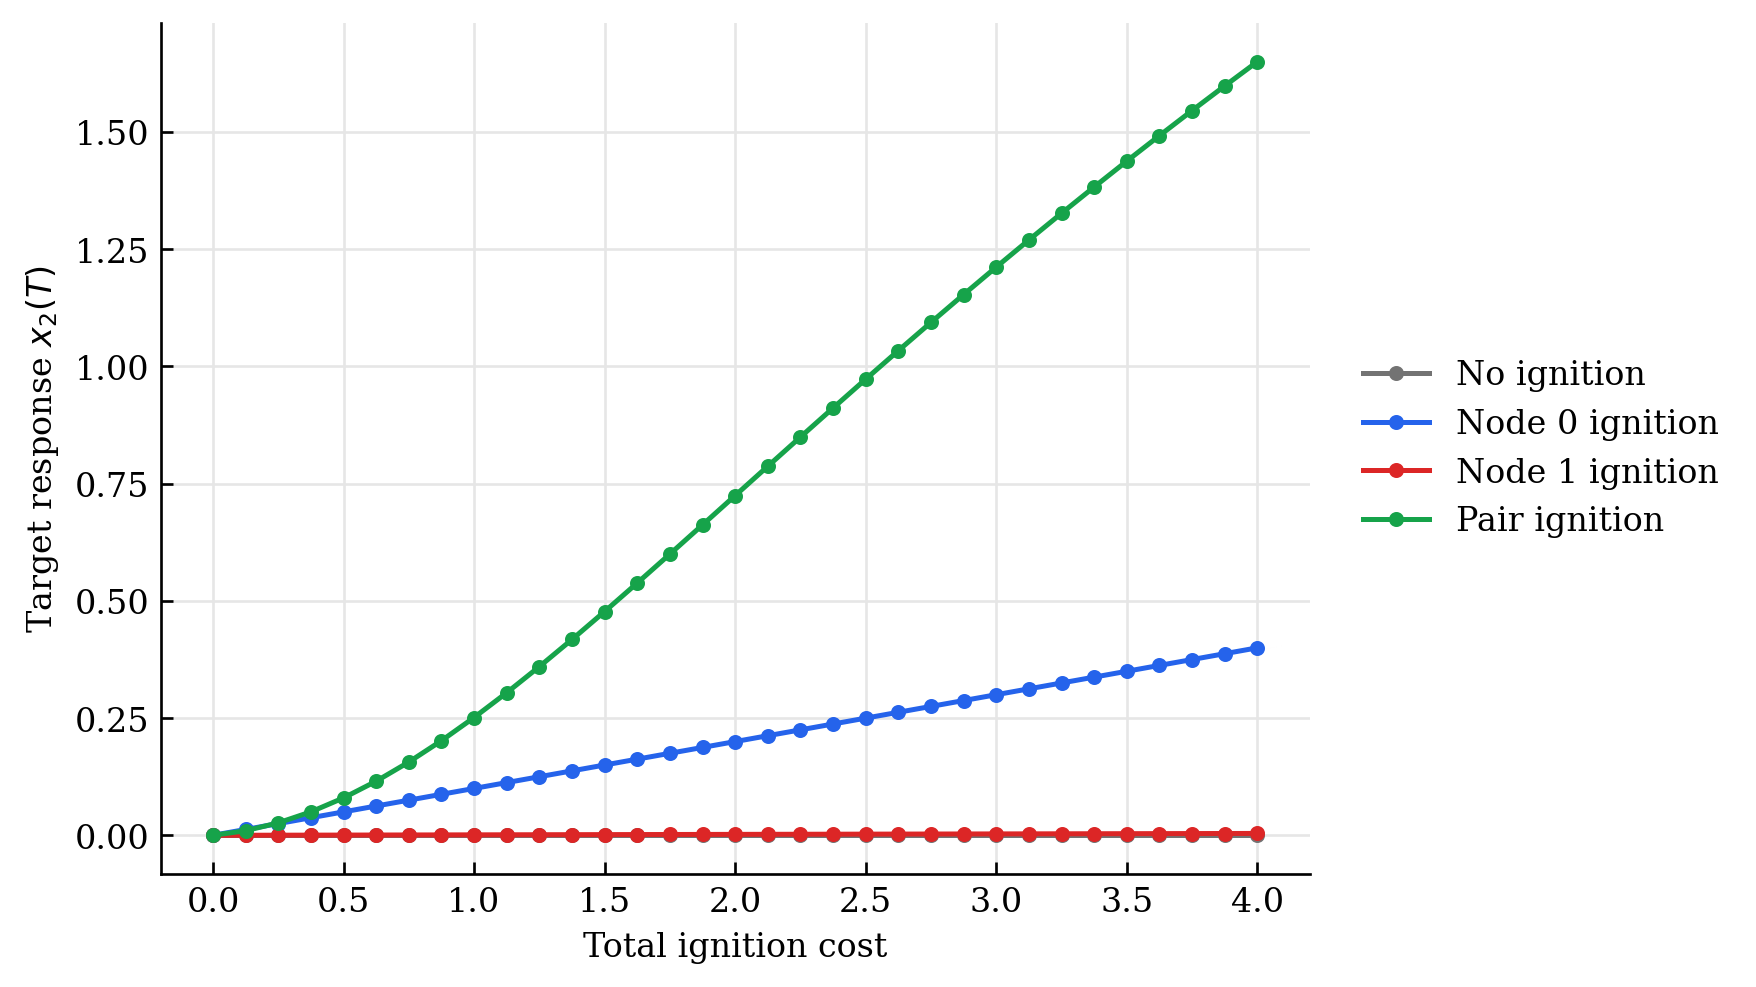

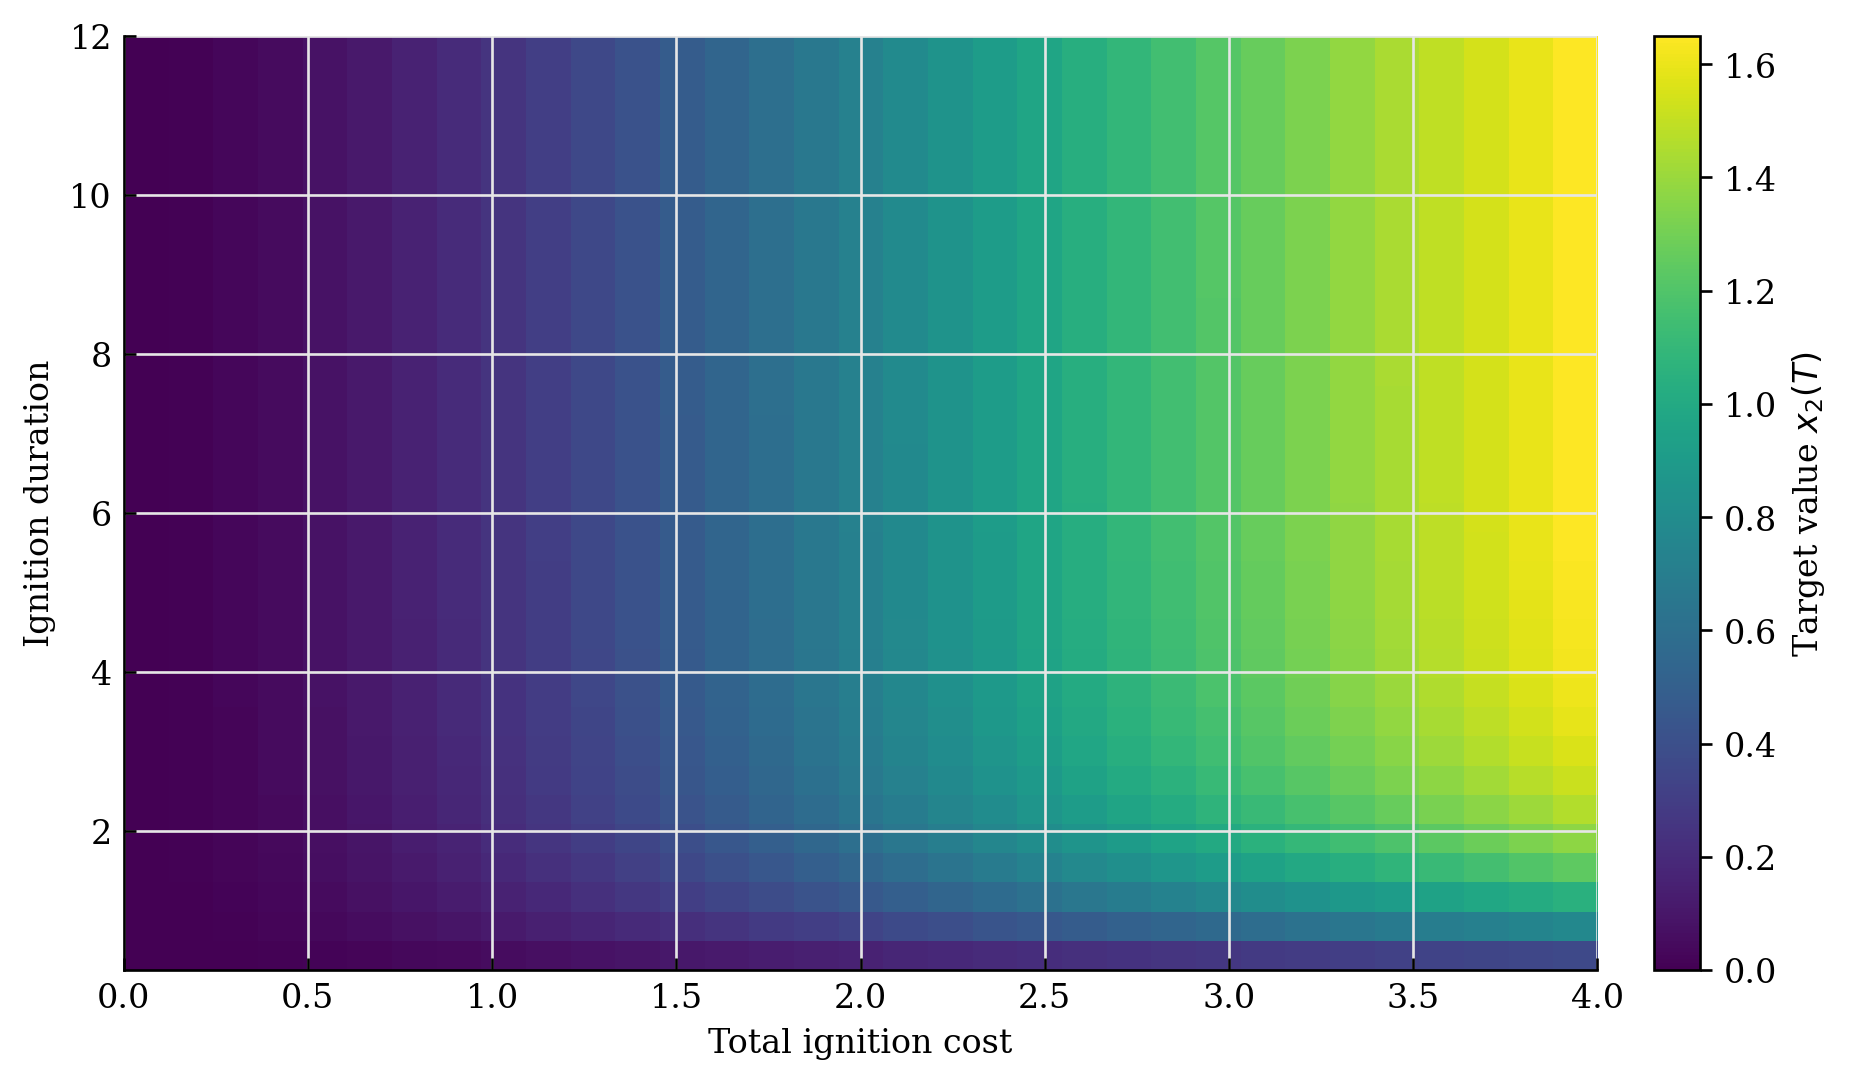

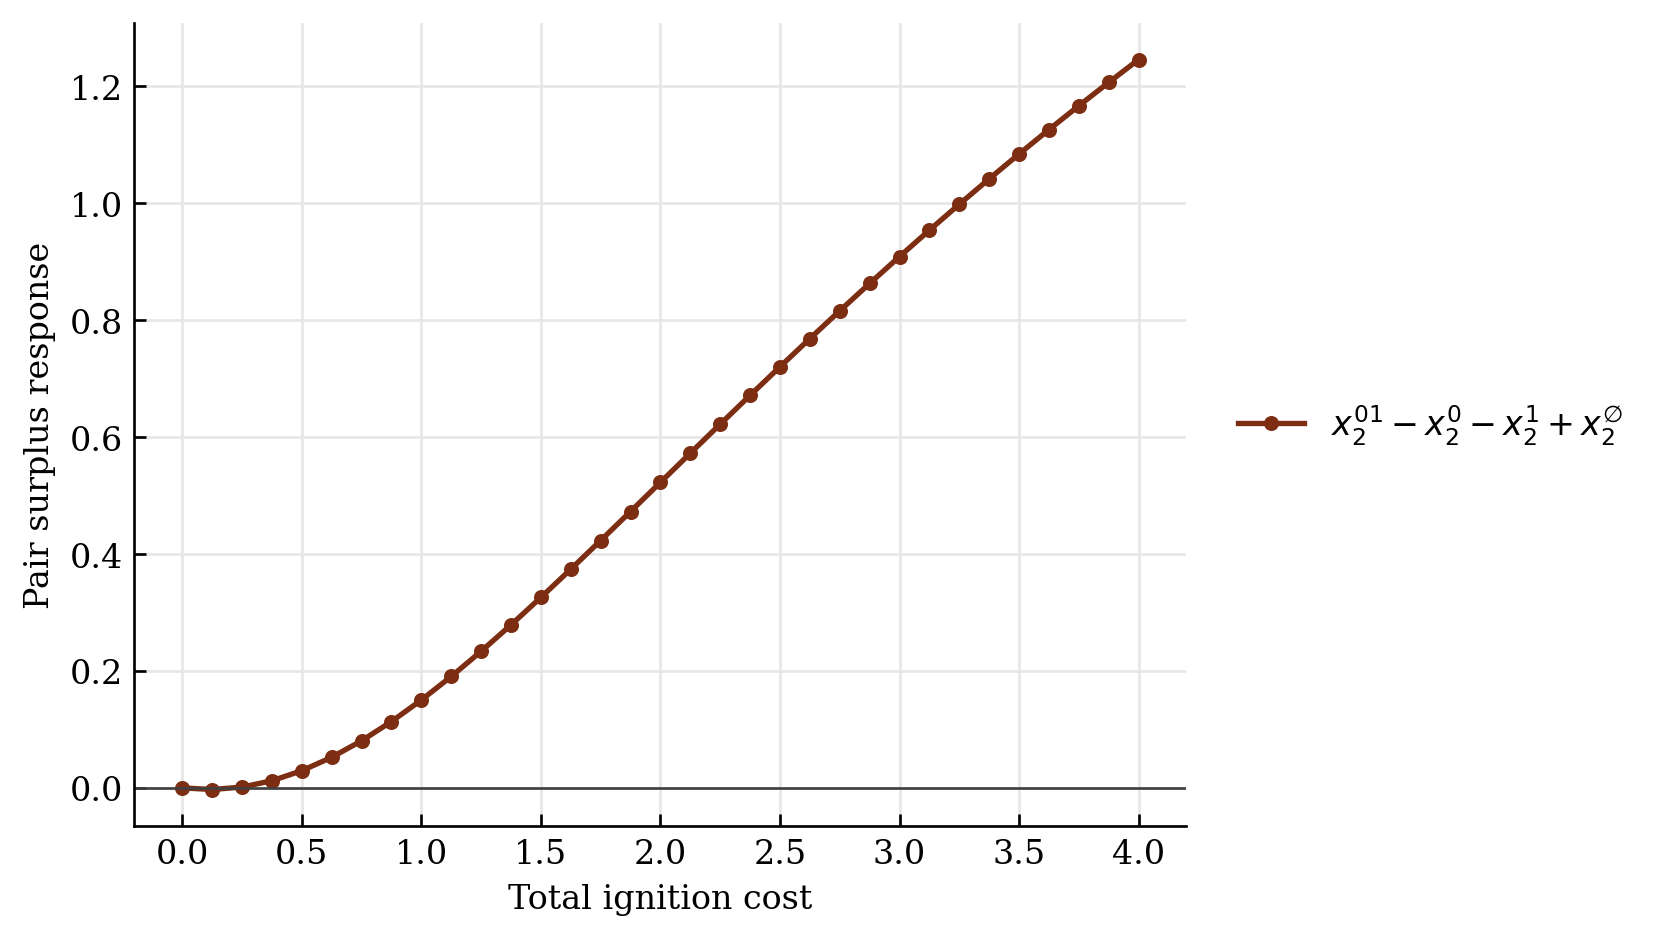

In [5]:
figure_paths = plot_sin_synergy_figures(results, config, FIGURE_DIR)
for name in [
    "sin_synergy_ignition_target_response",
    "sin_synergy_pair_duration_surface",
    "sin_synergy_ignition_pair_surplus",
]:
    display(Image(filename=str(figure_paths[name][0])))

In [6]:
display(Markdown(
    "**点火响应解释。** "
    f"当前高协同设置为 $\alpha={config.alpha_high:g}$，联合项为 $\log(1+\max(gx_0x_1,0))$，因此非负点火区间内目标响应不会被联合项压成负值。"
    f"最大双源剩余效应出现在总成本 `{summary['best_surplus_cost']:.3g}`，"
    f"对应 $x_2^{{01}}-x_2^0-x_2^1+x_2^\varnothing={summary['best_pair_surplus']:.4g}$。"
    f"该点的双源/最佳单源响应比为 `{summary['best_pair_gain_ratio']:.3g}`，说明联合点火不是两个单源曲线的简单相加。"
))

**点火响应解释。** 当前高协同设置为 $lpha=0.9$，联合项为 $\log(1+\max(gx_0x_1,0))$，因此非负点火区间内目标响应不会被联合项压成负值。最大双源剩余效应出现在总成本 `4`，对应 $x_2^{01}-x_2^0-x_2^1+x_2^arnothing=1.246$。该点的双源/最佳单源响应比为 `4.13`，说明联合点火不是两个单源曲线的简单相加。

## 单源 EI、联合 EI 与协同分解

这里使用 $[0,2]^2$ 上的非负随机双源干预分布，把目标终点或中间时间的 $x_2$ 作为响应变量，比较 $EI_0$、$EI_1$、$EI_{01}$ 和 $Syn_{01}=EI_{01}-EI_0-EI_1$。

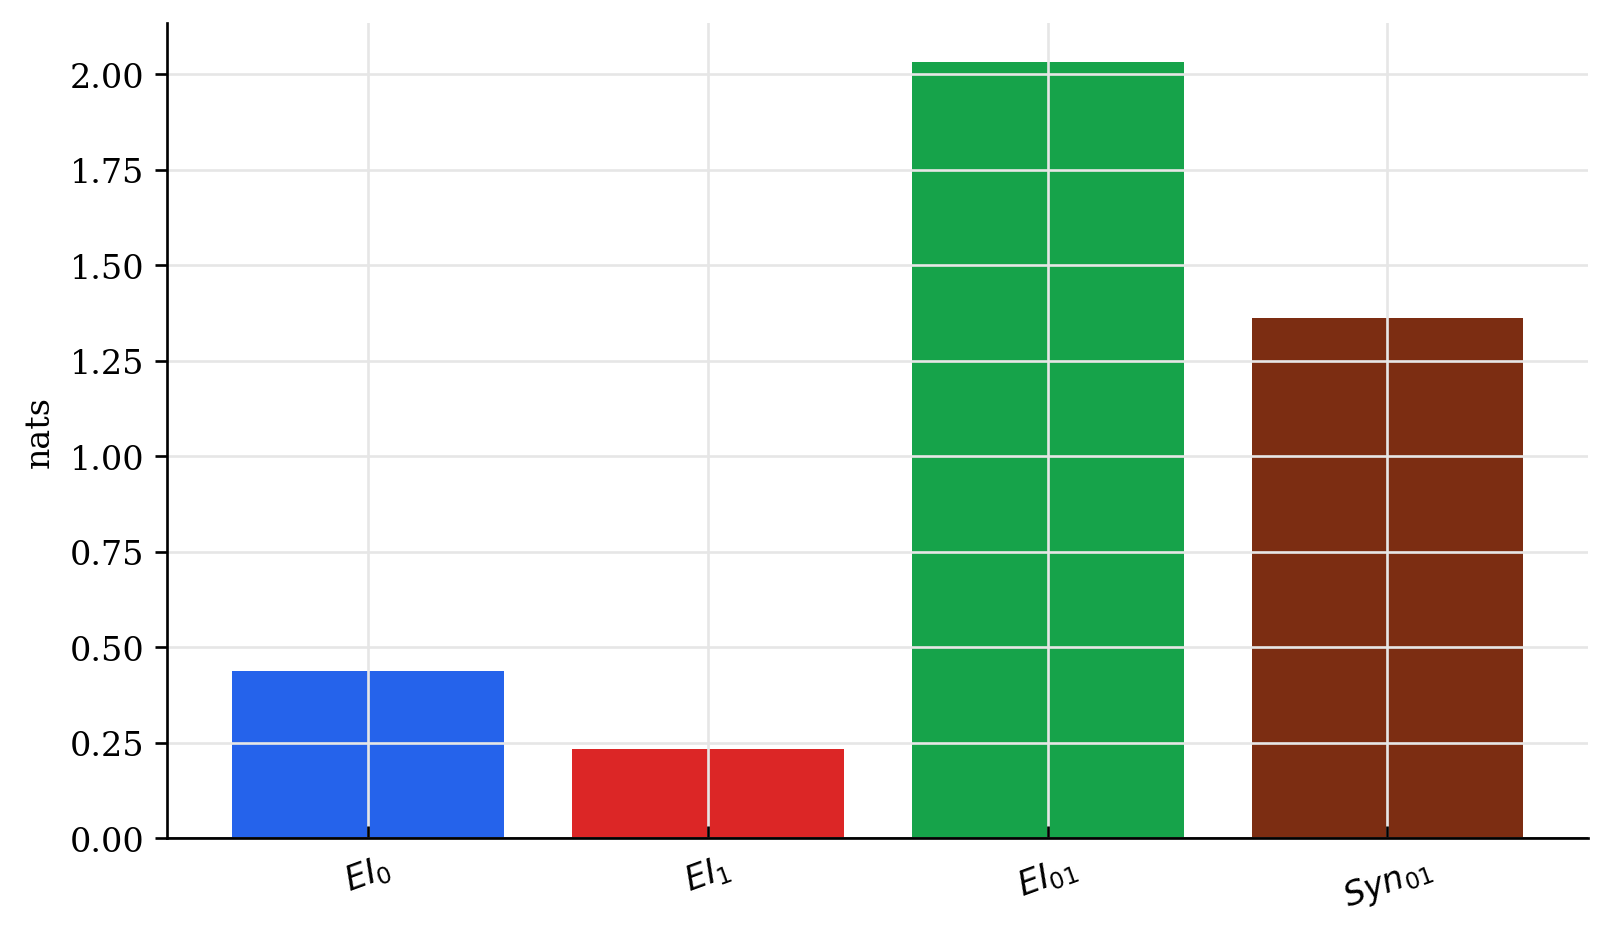

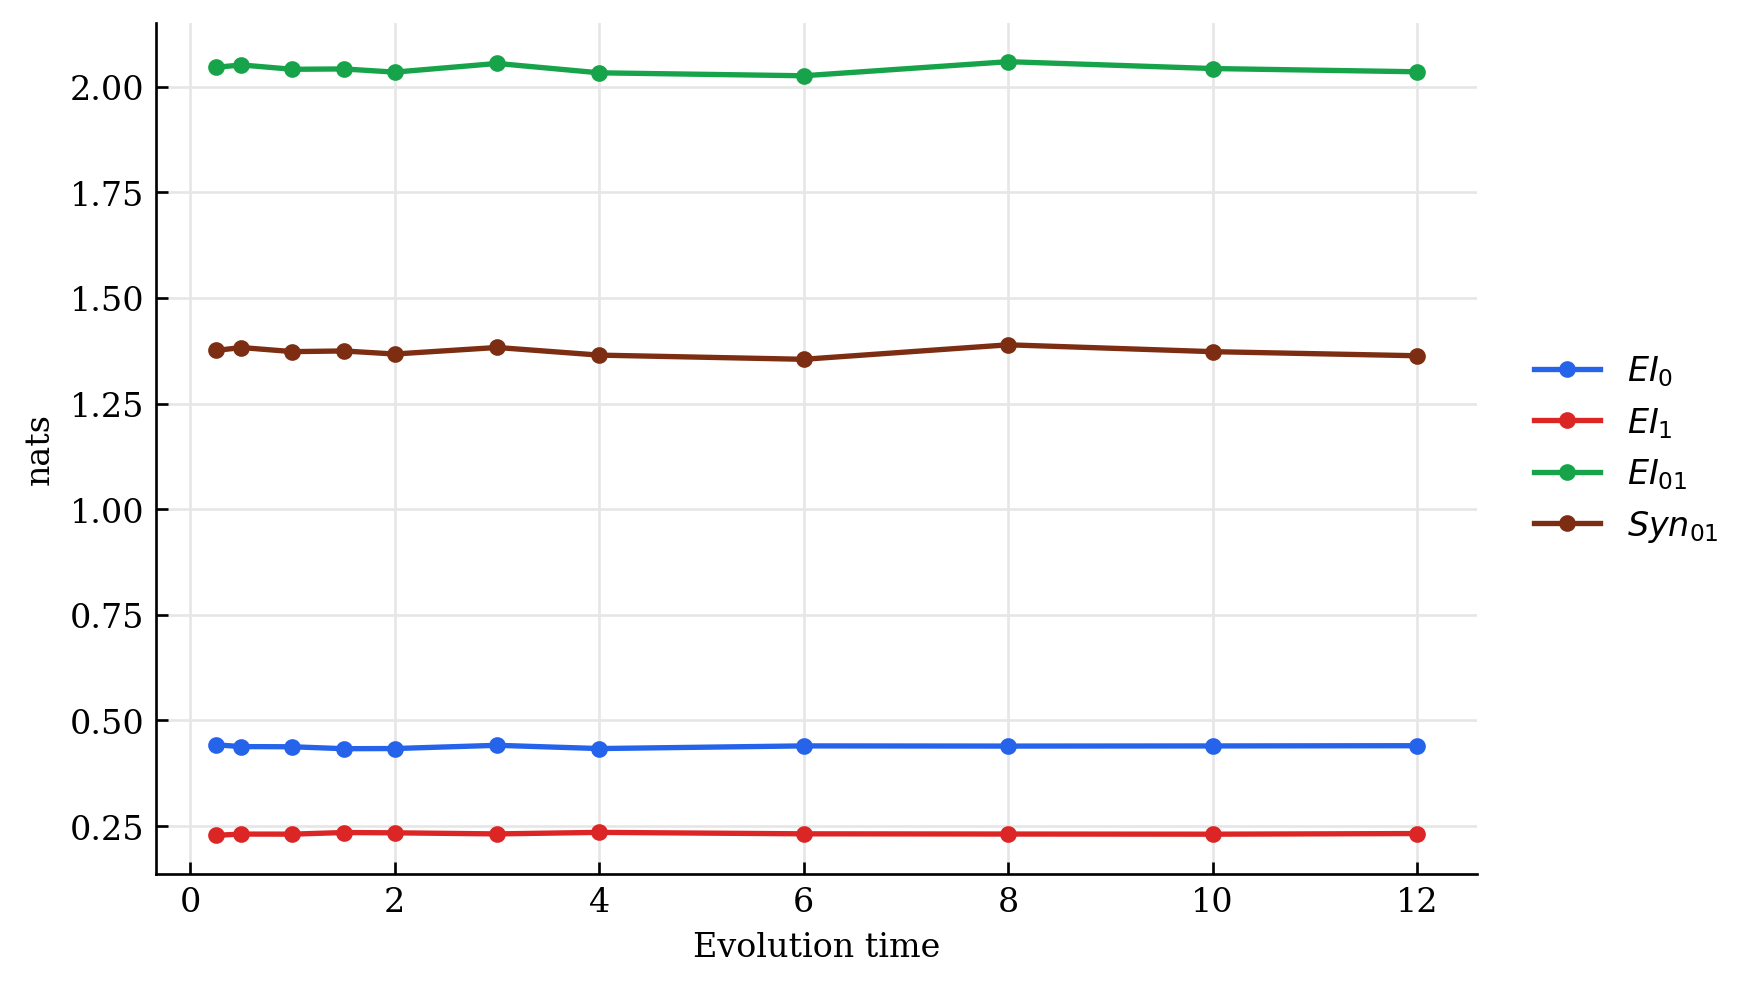

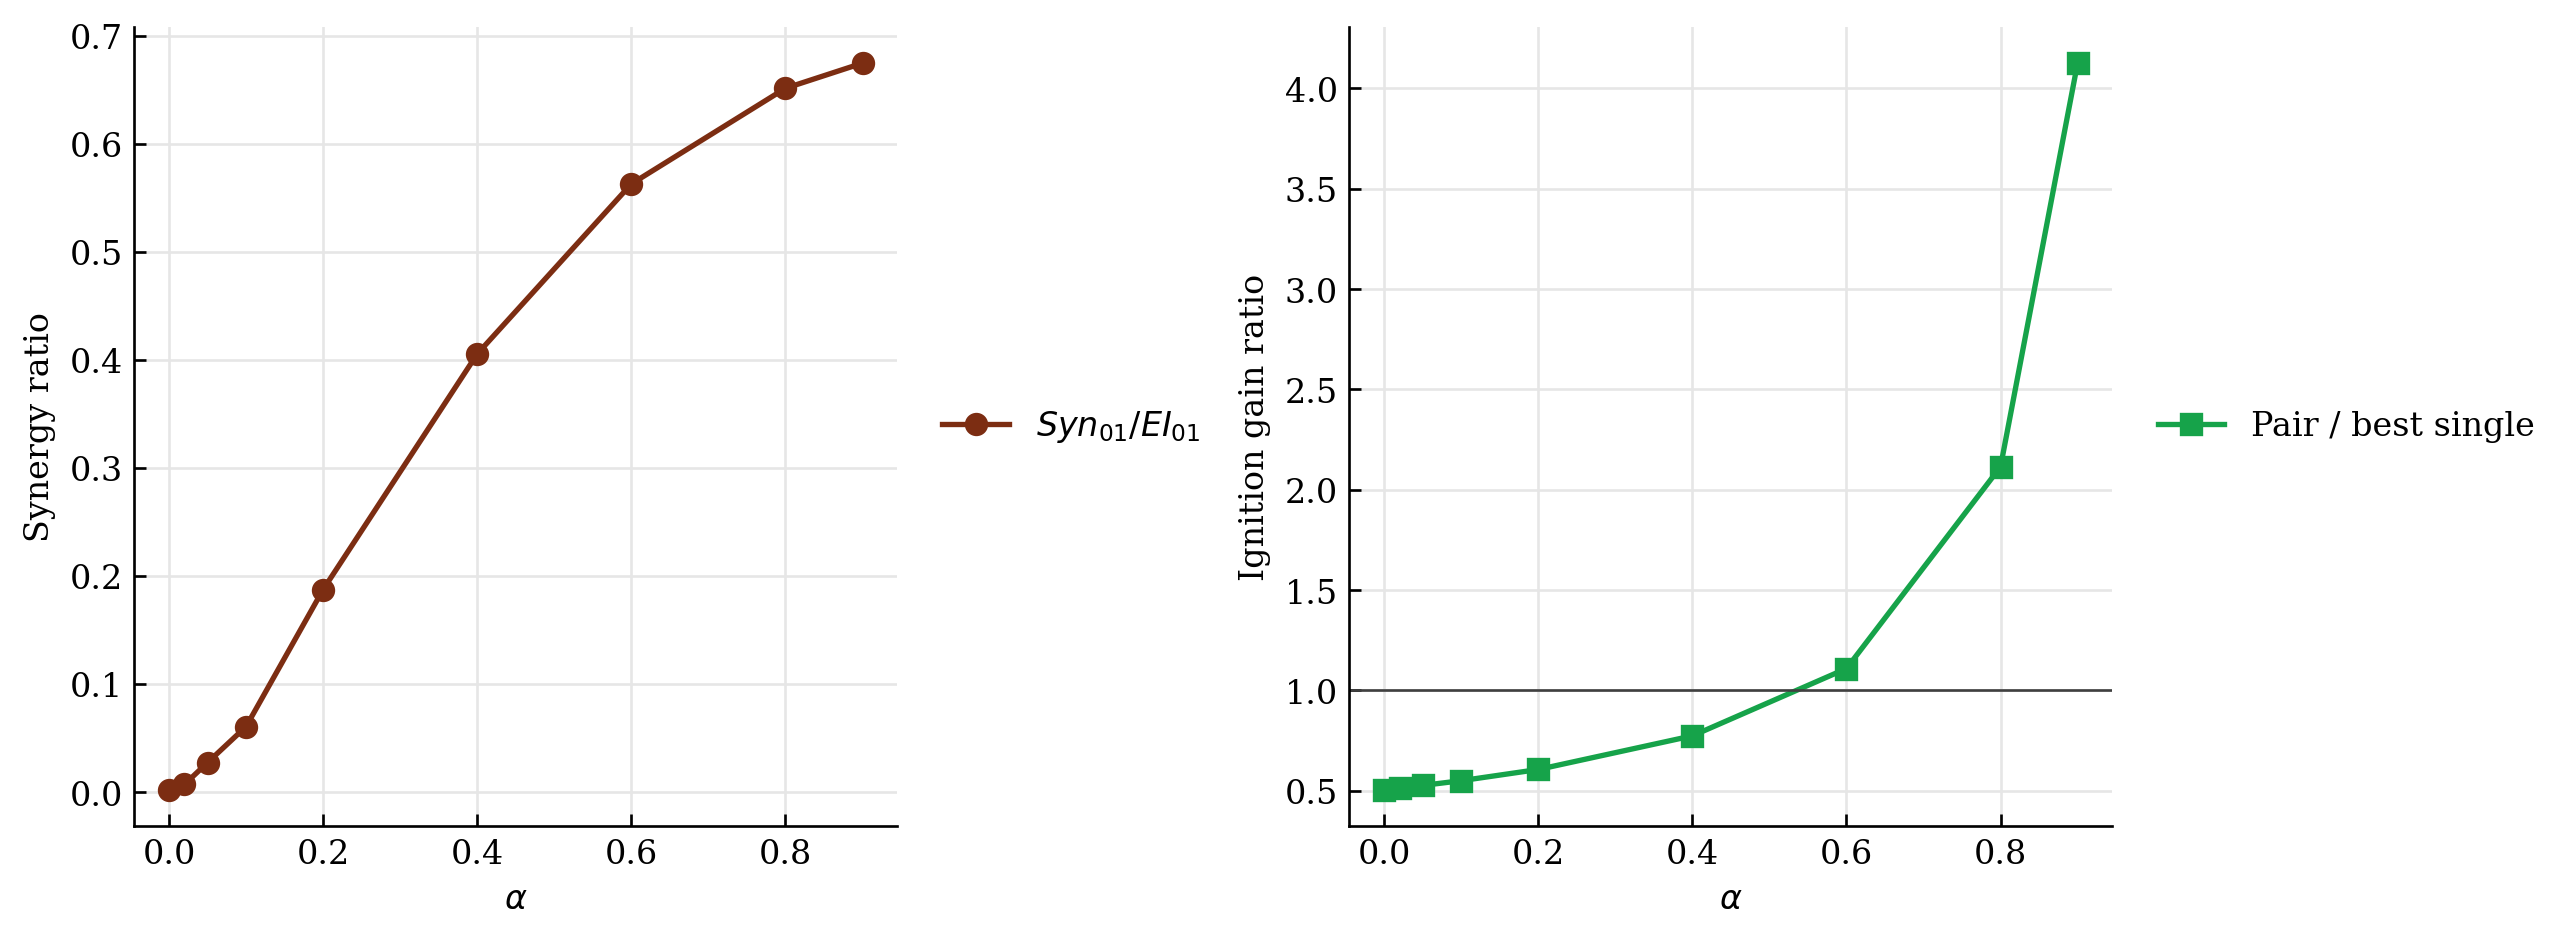

In [7]:
for name in [
    "sin_synergy_ei_decomposition",
    "sin_synergy_ei_time_curve",
    "sin_synergy_alpha_sweep_summary",
]:
    display(Image(filename=str(figure_paths[name][0])))

In [8]:
display(Markdown(
    "**单源 EI 与协同分解。** "
    f"在 $[{config.ei_cost_low:g},{config.ei_cost_high:g}]^2$ 的随机干预上，"
    f"$EI_0={summary['source_0_ei']:.4g}$、$EI_1={summary['source_1_ei']:.4g}$、"
    f"$EI_{{01}}={summary['joint_ei']:.4g}$、$Syn_{{01}}={summary['synergy']:.4g}$，"
    f"SynRatio={summary['synergy_ratio']:.3g}。"
    f"低协同设置 $\alpha={config.alpha_low:g}$ 时 SynRatio < 0.1，实际为 `{summary['low_alpha_synergy_ratio']:.3g}`，"
    f"联合/最佳单源收益比为 `{summary['low_alpha_pair_gain_ratio']:.3g}`；"
    f"高协同设置 $\alpha={config.alpha_high:g}$ 时 SynRatio > 0.6，实际为 `{summary['high_alpha_synergy_ratio']:.3g}`，"
    f"联合/最佳单源收益比升至 `{summary['high_alpha_pair_gain_ratio']:.3g}`。"
))

**单源 EI 与协同分解。** 在 $[0,2]^2$ 的随机干预上，$EI_0=0.4384$、$EI_1=0.2328$、$EI_{01}=2.032$、$Syn_{01}=1.361$，SynRatio=0.67。低协同设置 $lpha=0.05$ 时 SynRatio < 0.1，实际为 `0.0273`，联合/最佳单源收益比为 `0.526`；高协同设置 $lpha=0.9$ 时 SynRatio > 0.6，实际为 `0.674`，联合/最佳单源收益比升至 `4.13`。

## 多节点关键节点对联合点火

为了避免三节点网络过于简单，下面扩展为 6 节点受控网络 ODE：节点 $0\ldots4$ 是候选点火源，节点 $5$ 是目标/读出节点且不参与点火。网络中每个节点都有不同的入邻居，节点 $0\to1\to2\to0$ 构成一个三节点 feedback loop。

基础网络项为

$$\dot{x}_k=-\lambda_k x_k+\sum_j A_{kj}x_j,$$

目标节点额外接收协同读出和单源读出：

$$\dot{x}_5=-\lambda_5 x_5+\sum_j A_{5j}x_j+\alpha\sum_{(i,j)} w_{ij}\log(1+gx_i x_j)+(1-\alpha)\sum_i b_i x_i.$$

默认嵌入真实协同对 $(0,1)$、$(2,3)$、$(1,4)$，其余节点对作为对照。展示点火效果时直接报告联合点火后的目标响应 $x_5(T)$，不再除以 best single。


In [9]:
multi_config = MultiNodeSynergyIgnitionConfig(output_dir=OUTPUT_DIR)
multi_paths = multi_node_output_paths(multi_config)
# Cache names: multi_node_pair_synergy.csv, multi_node_pair_ignition_response.csv,
# multi_node_pair_summary.csv, multi_node_synergy_manifest.json.
# Public workflow helpers: estimate_multi_node_pair_synergy, build_multi_node_pair_ignition_table.
multi_results = load_or_run_multi_node_synergy_experiment(multi_config, force=FORCE_RECOMPUTE)
multi_summary = summarize_multi_node_synergy_results(multi_results)

display(pd.DataFrame([{ "artifact": key, "path": str(value) } for key, value in multi_results["paths"].items()]))


,artifact,path
0,pair_synergy_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
1,pair_ignition_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
2,pair_summary_csv,/Users/yangmingzhe/Desktop/code/github/EISyn/r...
3,manifest_json,/Users/yangmingzhe/Desktop/code/github/EISyn/r...


In [10]:
multi_pair_cols = [
    "pair_i",
    "pair_j",
    "is_embedded_synergy_pair",
    "embedded_synergy_weight",
    "joint_ei",
    "synergy",
    "synergy_ratio",
    "pair_response_at_max_cost",
    "pair_surplus_at_max_cost",
    "rank_synergy",
]
display(multi_results["pair_summary"].sort_values("rank_synergy")[multi_pair_cols])
display(Markdown(
    "**多节点点火解释。** "
    f"Syn 排名第一的节点对是 `{multi_summary['top_synergy_pair']}`，"
    f"对应最大成本下联合点火目标响应 `{multi_summary['top_synergy_pair_response']:.3g}`。"
    f"Syn 与最大成本下 pair response 的 Spearman 相关为 `{multi_summary['spearman_synergy_pair_response']:.3g}`，"
    f"与 pair surplus 的 Spearman 相关为 `{multi_summary['spearman_synergy_pair_surplus']:.3g}`。"
))


,pair_i,pair_j,is_embedded_synergy_pair,embedded_synergy_weight,joint_ei,synergy,synergy_ratio,pair_response_at_max_cost,pair_surplus_at_max_cost,rank_synergy
0,0,1,True,1.00,0.523345,0.153654,0.293600,1.842748,-0.147333,1
1,1,2,False,0.00,0.318791,0.036920,0.115811,0.889056,-0.184060,2
2,1,4,True,0.40,0.290666,0.035480,0.122064,1.079196,-0.126427,3
3,0,3,False,0.00,0.250740,0.027473,0.109566,0.854842,-1.075054,4
4,1,3,False,0.00,0.314616,0.025967,0.082534,0.745611,-0.285893,5
5,2,3,True,0.65,0.158285,0.022836,0.144274,1.394984,0.382052,6
6,0,2,False,0.00,0.237479,0.020989,0.088383,0.946917,-1.024592,7
7,2,4,False,0.00,0.111738,0.009753,0.087286,0.556522,-0.630529,8
8,3,4,False,0.00,0.118251,0.009488,0.080236,0.539819,-0.605620,9
9,0,4,False,0.00,0.198773,0.008969,0.045124,1.054136,-1.049879,10


**多节点点火解释。** Syn 排名第一的节点对是 `(0, 1)`，对应最大成本下联合点火目标响应 `1.84`。Syn 与最大成本下 pair response 的 Spearman 相关为 `0.442`，与 pair surplus 的 Spearman 相关为 `0.503`。

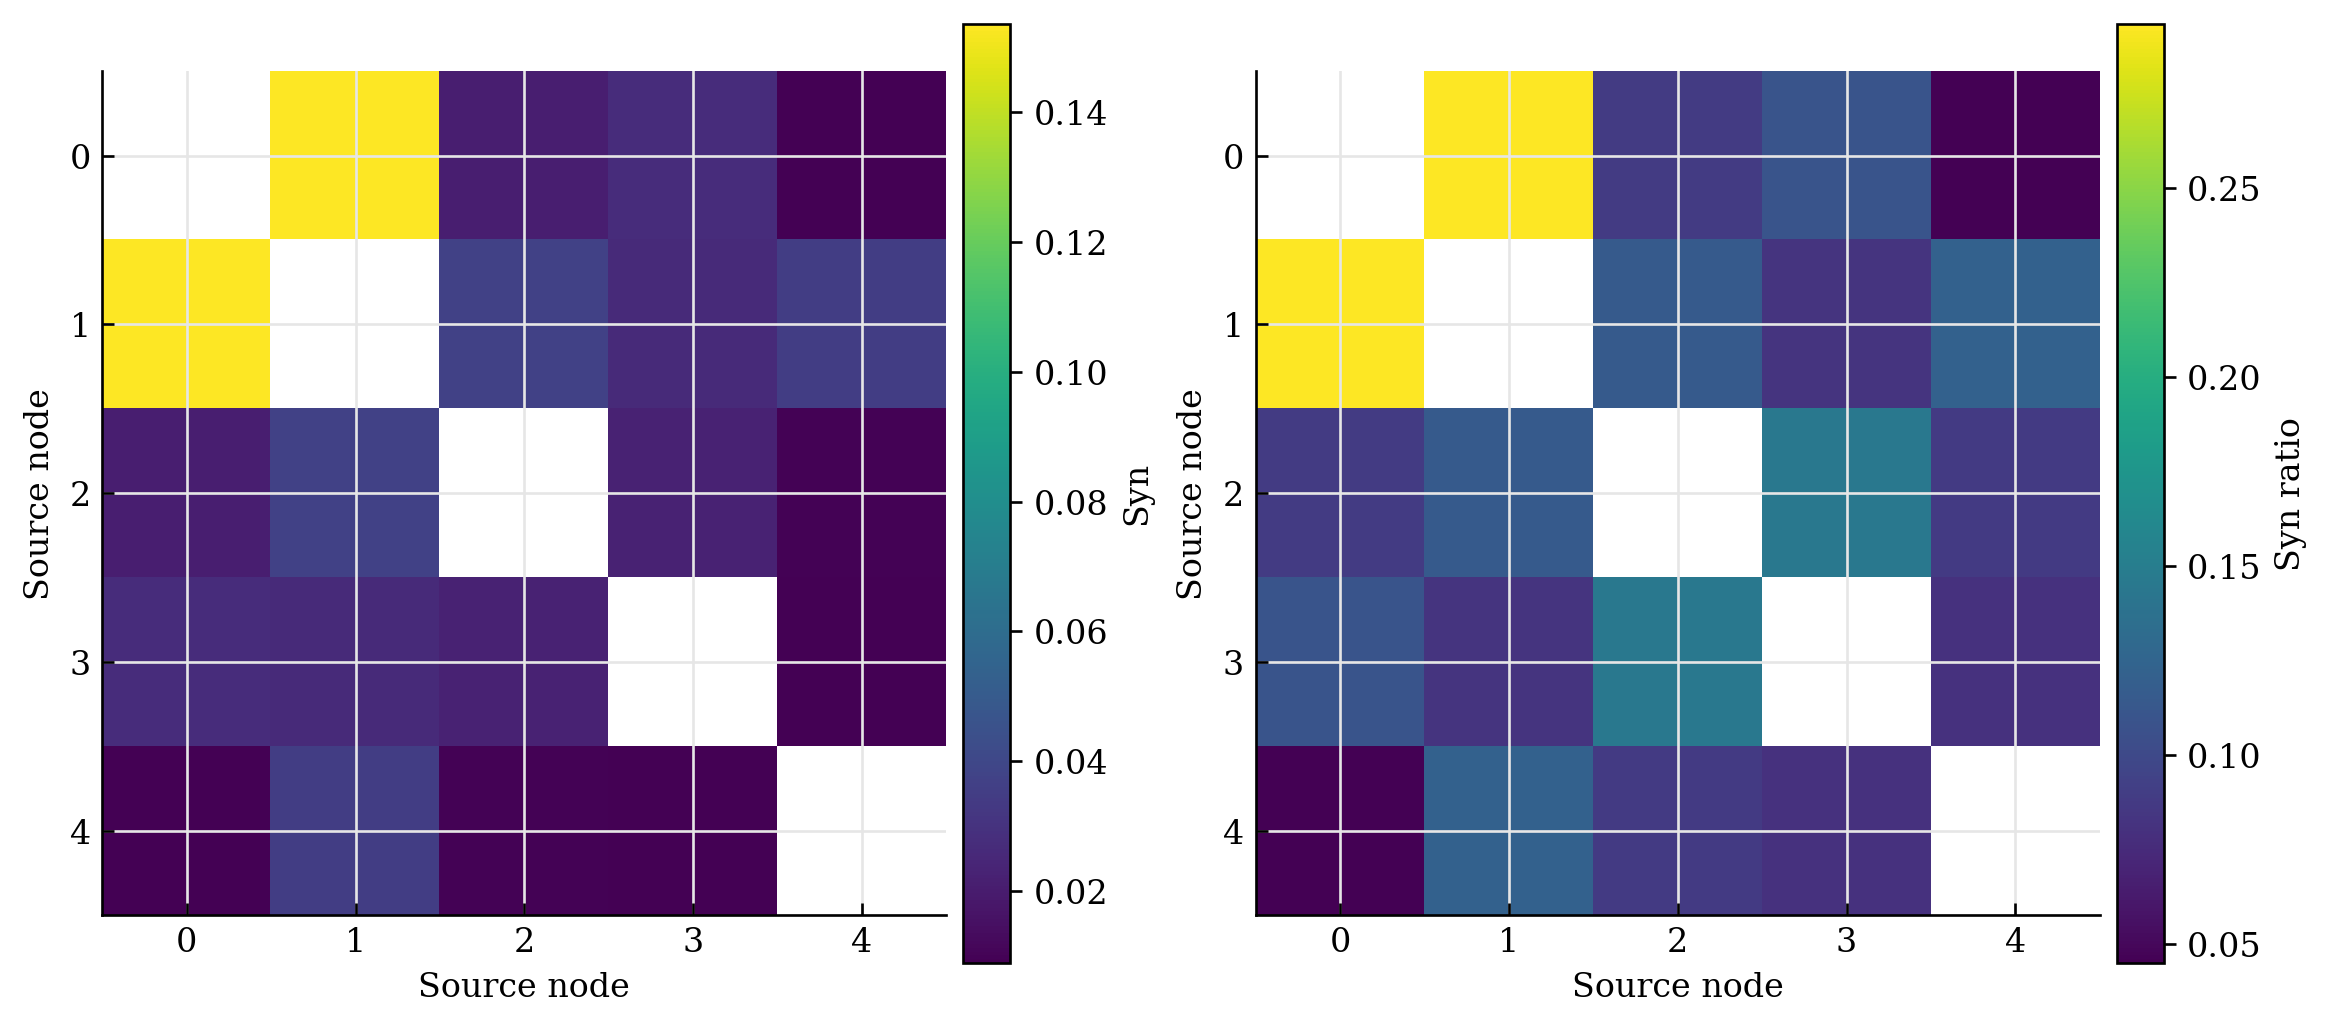

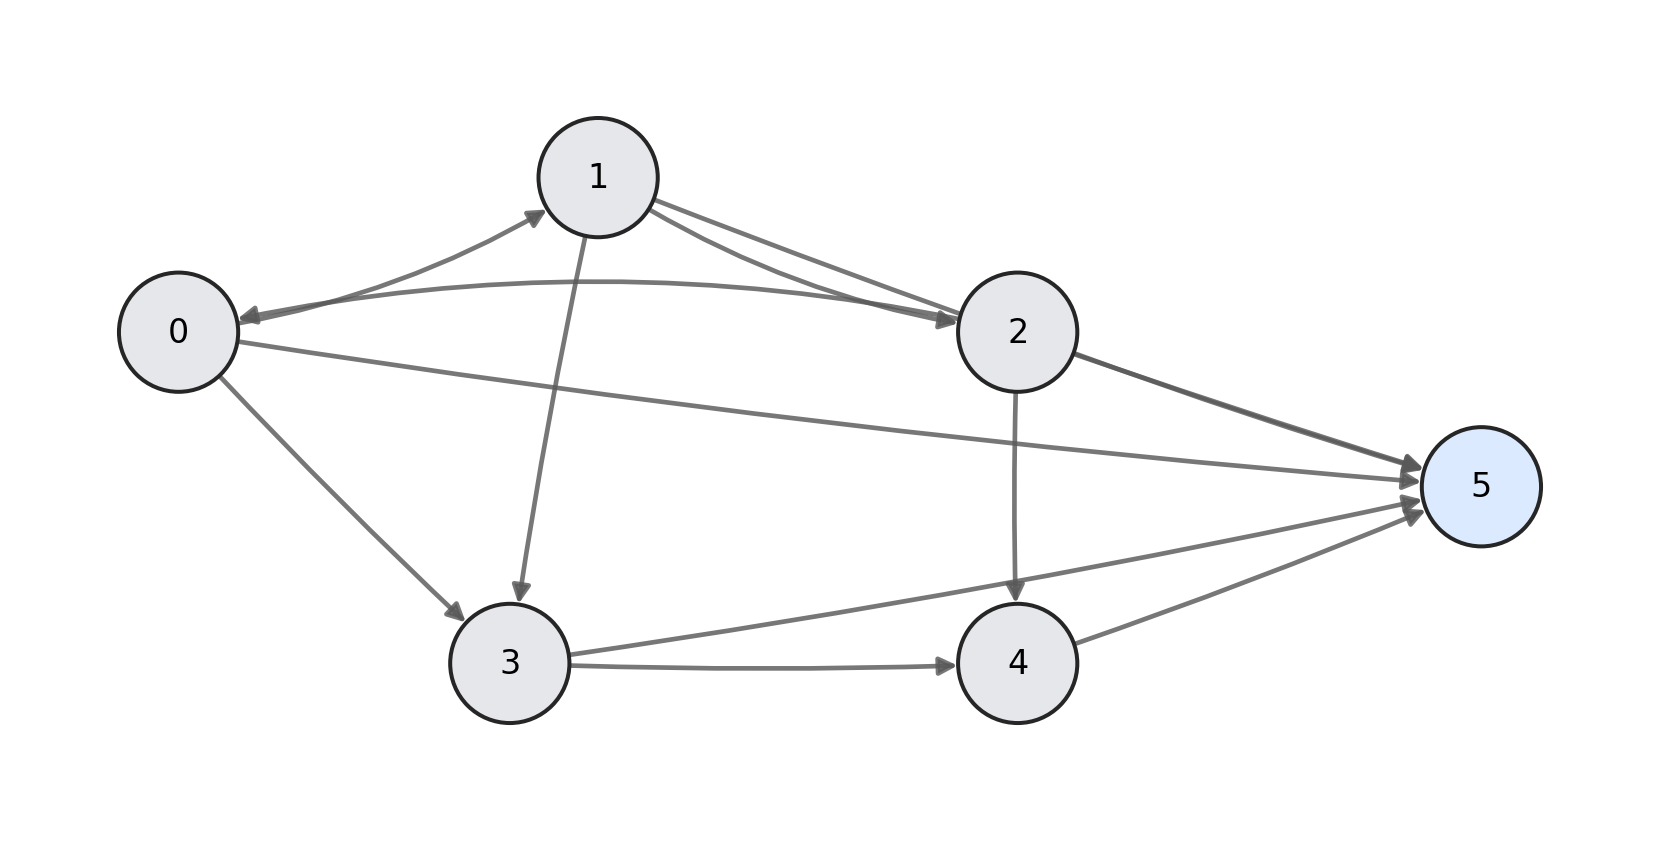

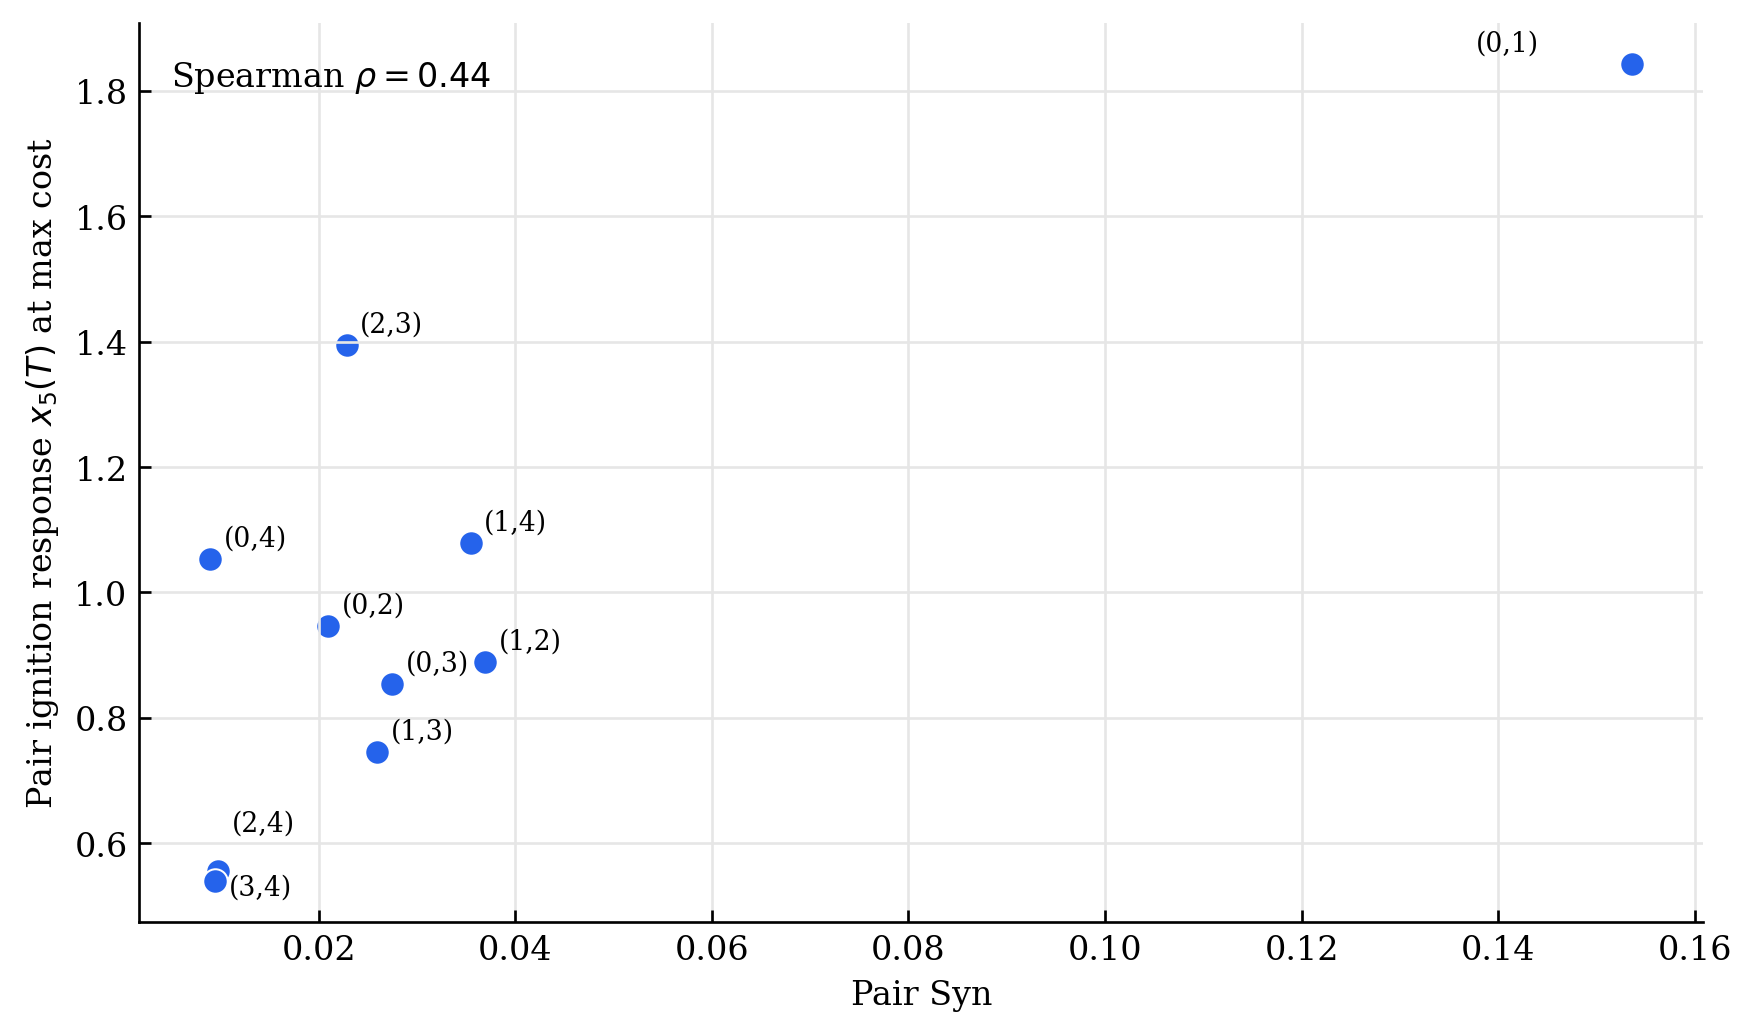

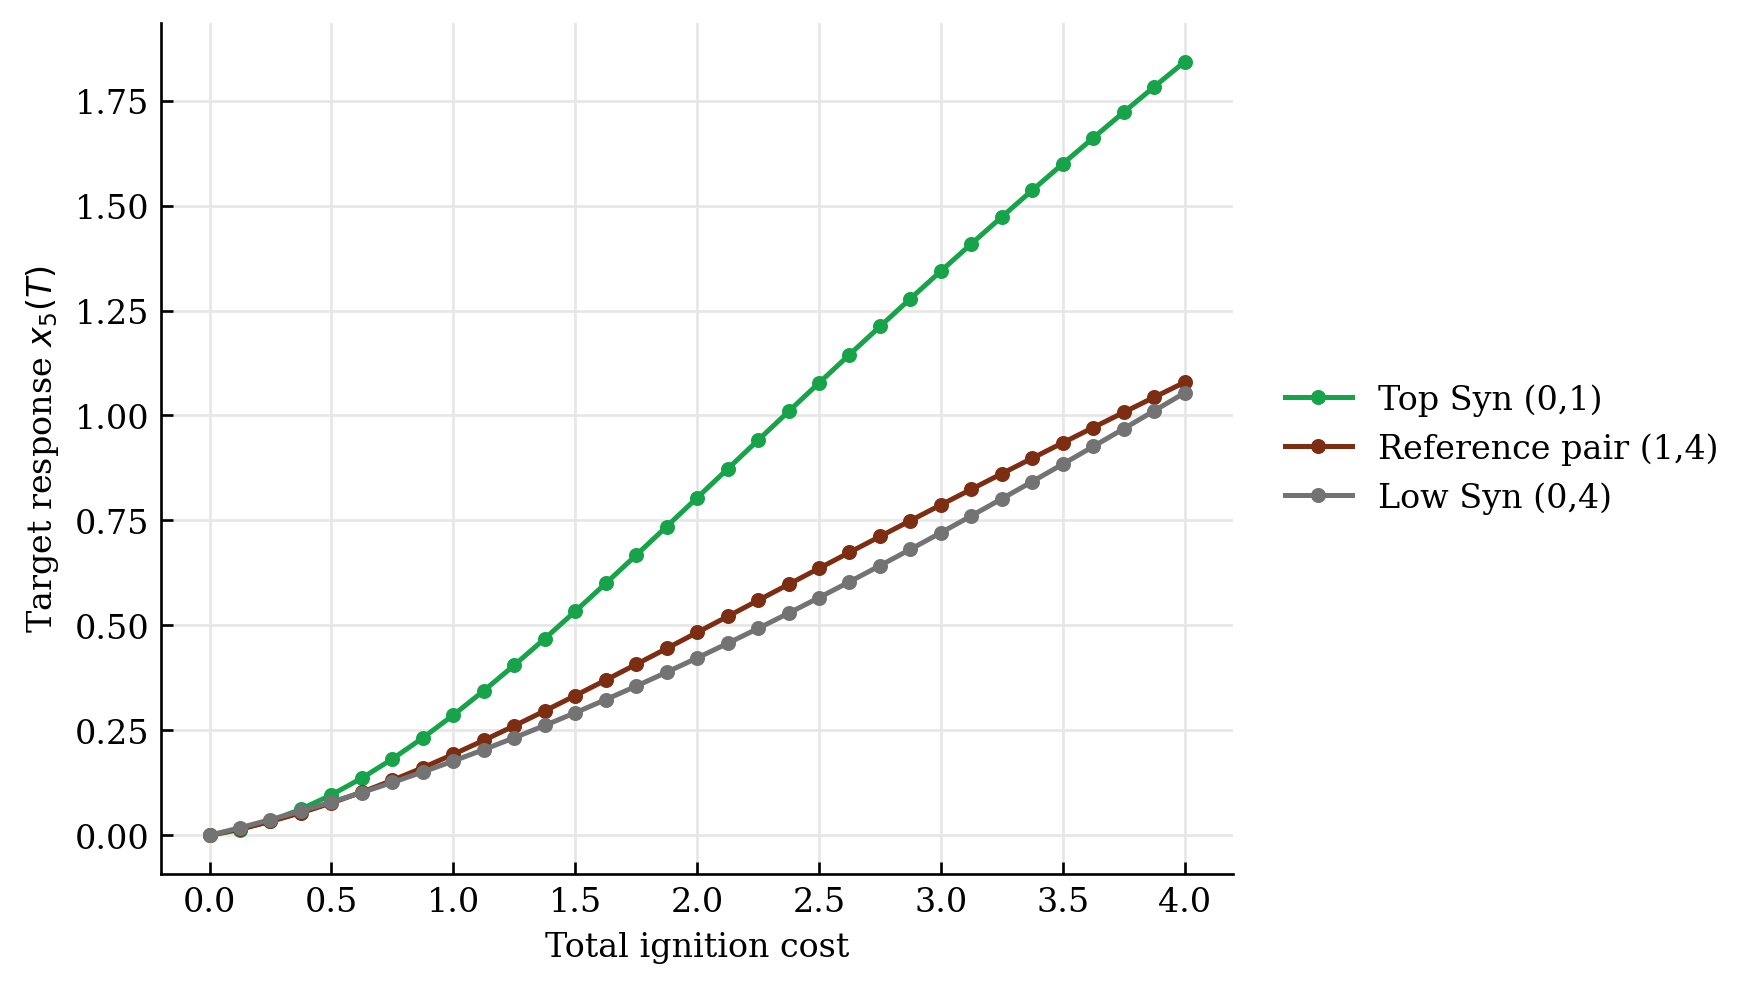

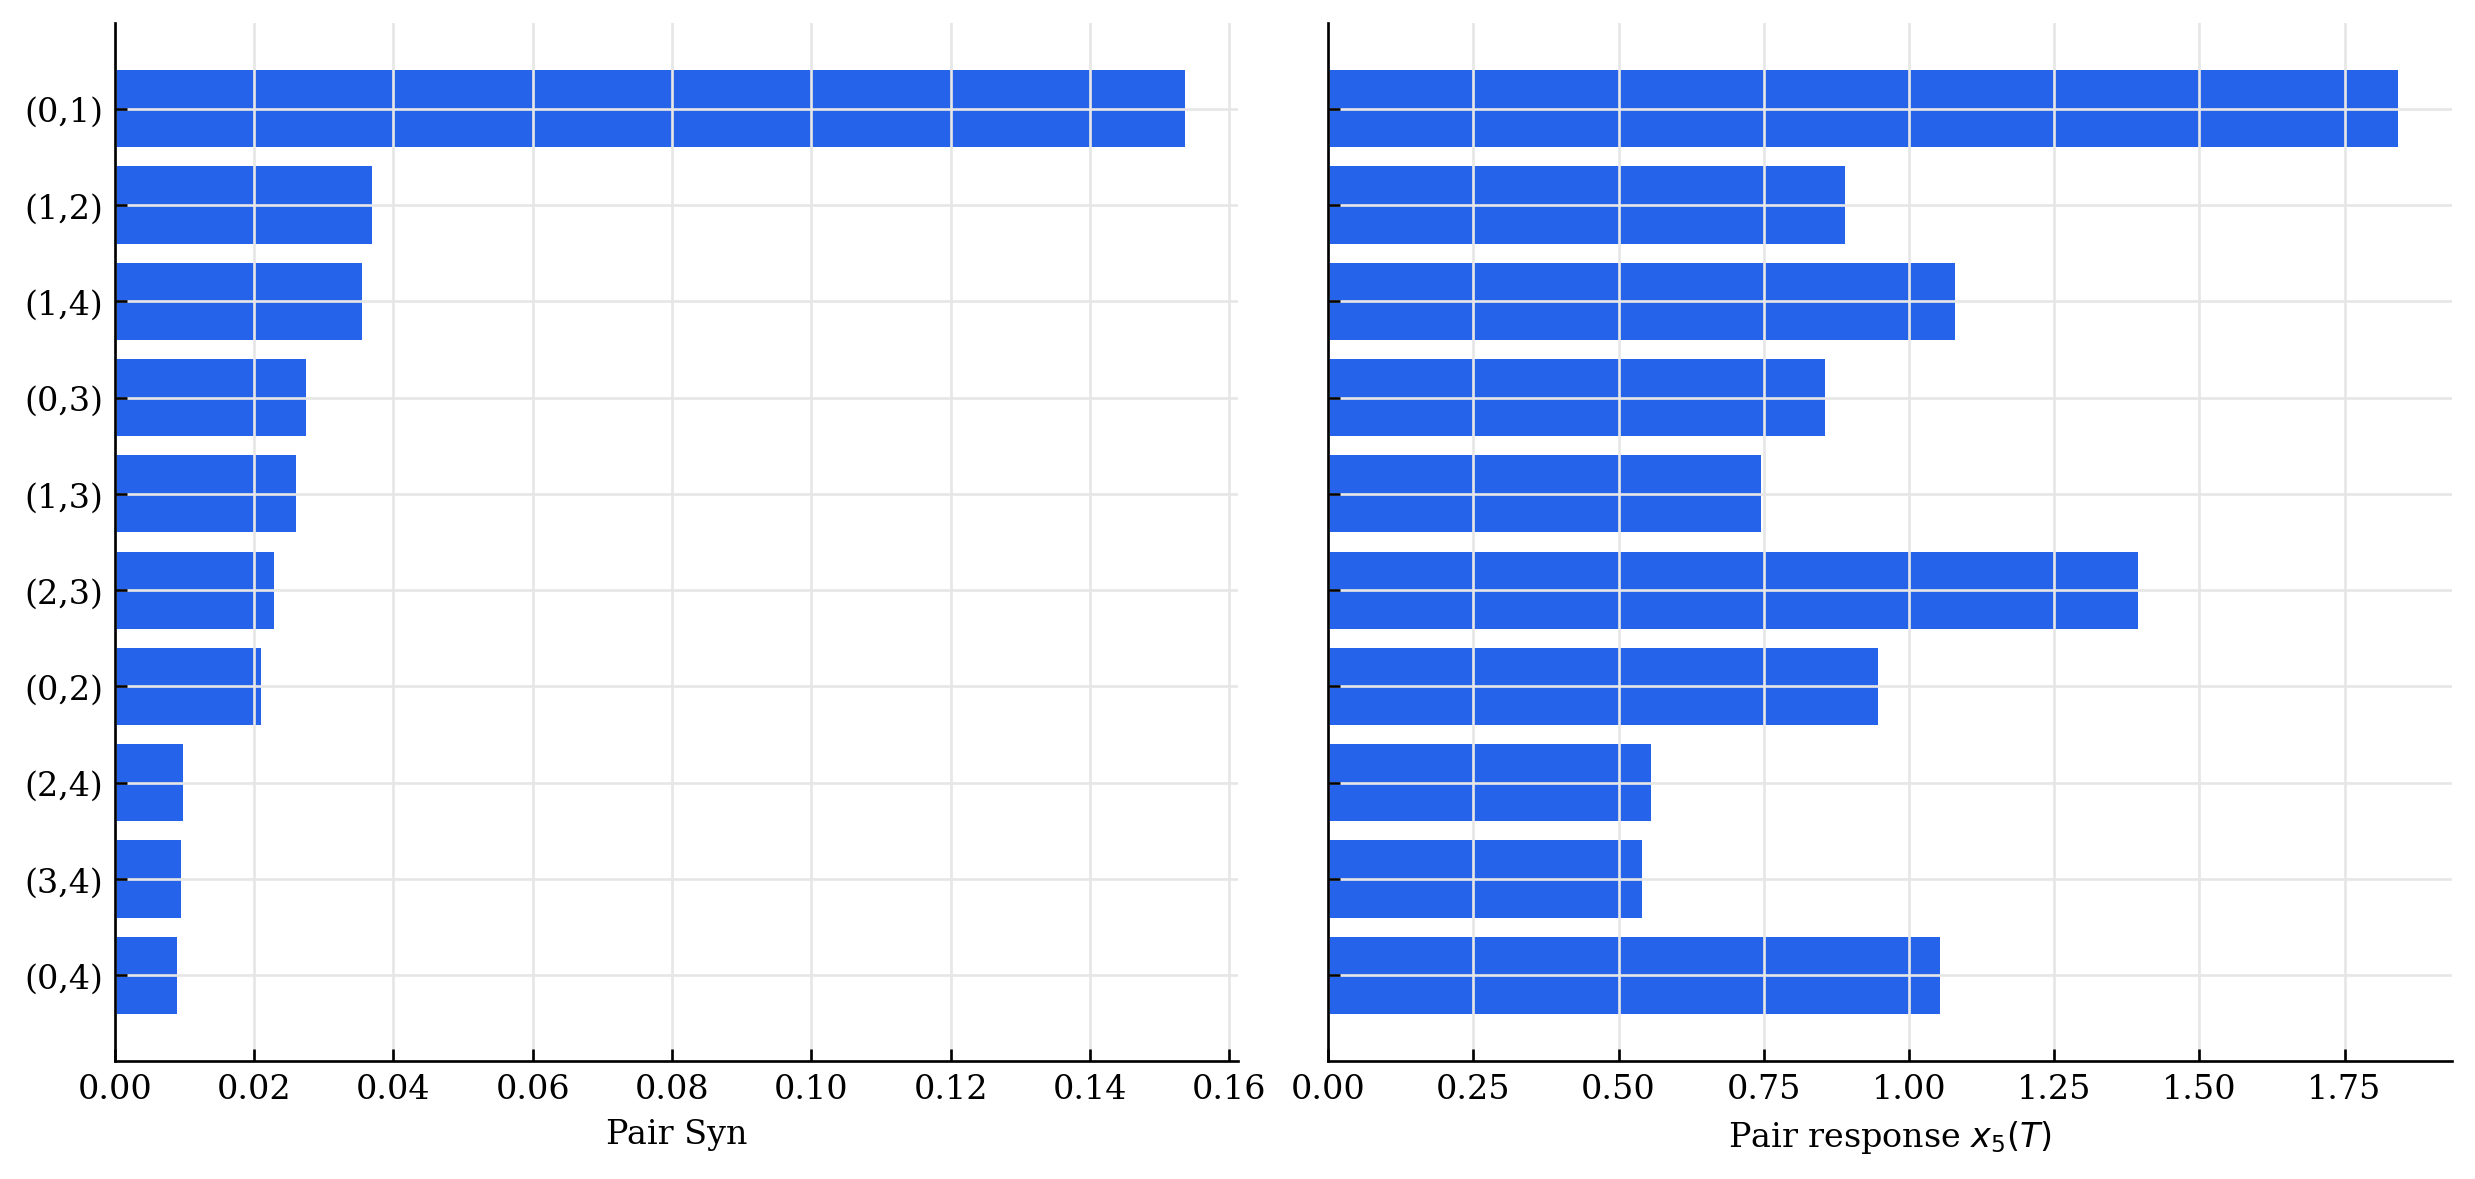

In [11]:
multi_figure_paths = plot_multi_node_synergy_figures(multi_results, multi_config, FIGURE_DIR)
figure_paths.update(multi_figure_paths)
for name in [
    "multi_node_pair_synergy_heatmap",
    "multi_node_network_topology",
    "multi_node_synergy_vs_pair_response",
    "multi_node_pair_response_curves",
    "multi_node_pair_summary_rankings",
]:
    display(Image(filename=str(multi_figure_paths[name][0])))


In [12]:
write_sin_synergy_figure_manifest(
    config,
    figure_paths,
    manifest_path=FIGURE_MANIFEST_JSON,
    notes_path=FIGURE_NOTES_MD,
)

print("Figure directory:", FIGURE_DIR)
print("Figure manifest:", FIGURE_MANIFEST_JSON)
print("Figure notes:", FIGURE_NOTES_MD)

Figure directory: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/figures
Figure manifest: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/figure_manifest.json
Figure notes: /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_three_node_synergy/figure_notes.md
